# Sample Efficiency and Thresholds

Goal: compare how fast algorithms reach key quality thresholds.

Expected takeaway: which methods reach strong pass@k levels earlier with fewer steps.


In [1]:
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

DATA_DIR_CANDIDATES = [
    Path.cwd() / "final_results" / "data",
    Path.cwd().parent / "final_results" / "data",
    Path.cwd() / "data",
    Path.cwd().parents[1] / "final_results" / "data",
    Path(__file__).resolve().parents[1] / "data" if '__file__' in globals() else Path.cwd() / "final_results" / "data",
]

# Robust data path resolver (works when running from repo root or final_results/tools)

def resolve_data_path(filename: str) -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "final_results" / "data" / filename,
        cwd / "data" / filename,
    ]
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data" / filename)
        candidates.append(parent / "data" / filename)
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename} in candidates: {candidates}")


combined_path = resolve_data_path("combined_wide.csv")
combined = pd.read_csv(combined_path)
combined = combined.drop(columns=[c for c in combined.columns if c.lower().startswith("unnamed")], errors="ignore")
combined["Step"] = pd.to_numeric(combined["Step"], errors="coerce")

metric_cols = ["avg@32", "pass@1", "pass@2", "pass@4", "pass@8", "pass@16", "pass@32", "pass@64", "pass@128"]
for c in metric_cols:
    combined[c] = pd.to_numeric(combined[c], errors="coerce")

passk_cols = [c for c in metric_cols if c.startswith("pass@")]
passk_ks = [int(c.split("@")[1]) for c in passk_cols]

final_step = int(combined["Step"].max())

# Focus algorithms + display labels
prefix = "qwen2.5-1.5b-2gpu-"
label_to_algo = {
    "PPO": f"{prefix}PPO",
    "PPO-2": f"{prefix}PPO-2",
    "PPO-8": f"{prefix}PPO-8",
    "GRPO": f"{prefix}GRPO",
    "risk-baseline1-v3-cvarupp25-iqn-1": f"{prefix}PPO-risk-baseline1-v3-cvarupper25-iqn-1",
    "reweight-baseline1-v3-cvarupp25-iqn-8": f"{prefix}PPO-reweight-baseline1-v3-cvarupper25-iqn-8",
}

focus_labels = list(label_to_algo.keys())
focus_algos = [label_to_algo[k] for k in focus_labels]

combined = combined[combined["algorithm"].isin(focus_algos)].copy()
algo_to_label = {v: k for k, v in label_to_algo.items()}
combined["label"] = combined["algorithm"].map(algo_to_label)

# Muted, premium-ish palette (extended from overview cell)
colors = ["#537594", "#EB8C3E", "#36721C", "#4AB1AC", "#8C5A3C", "#7A6E3A"]
markers = ["o", "s", "^", "D", "P", "X"]
color_map = dict(zip(focus_labels, colors))
marker_map = dict(zip(focus_labels, markers))

# Aggregate across seeds for smoother curves
agg = combined.groupby(["Step", "label"], as_index=False)[metric_cols].mean()

# Helpers
PLOT_COUNTER = 0

def new_fig(title: str):
    global PLOT_COUNTER
    PLOT_COUNTER += 1
    plt.figure()
    plt.title(title)


In [2]:
metrics = ["pass@1", "pass@8", "pass@32"]
thresholds = [0.2, 0.3, 0.4]

# Earliest step to reach each threshold
records = []
for algo in combined["label"].unique():
    for seed in combined["seed"].unique():
        sub = combined[(combined["label"] == algo) & (combined["seed"] == seed)].sort_values("Step")
        for metric in metrics:
            for thr in thresholds:
                hit = sub[sub[metric] >= thr]
                step = hit["Step"].iloc[0] if len(hit) else np.nan
                records.append({"label": algo, "seed": seed, "metric": metric, "threshold": thr, "step": step})

hits = pd.DataFrame.from_records(records)


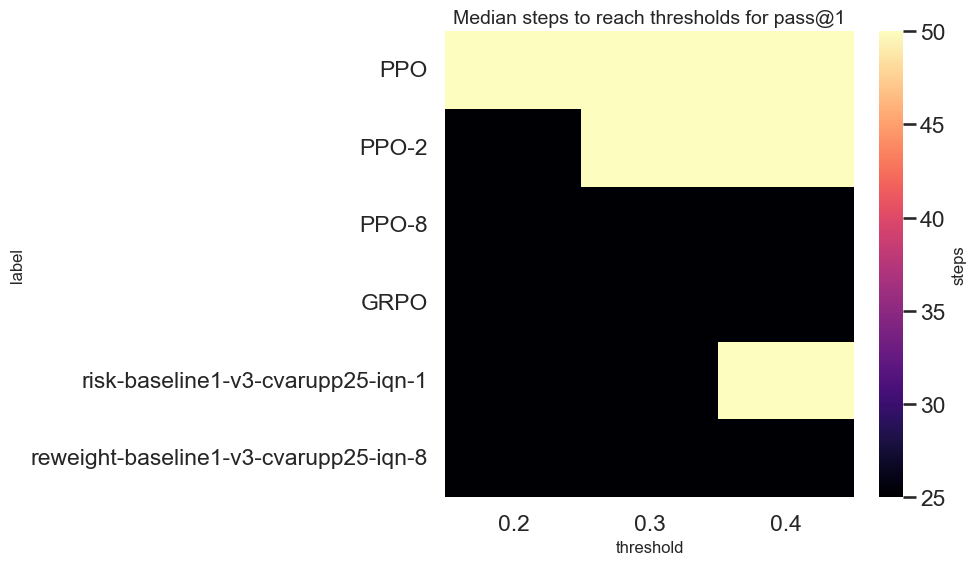

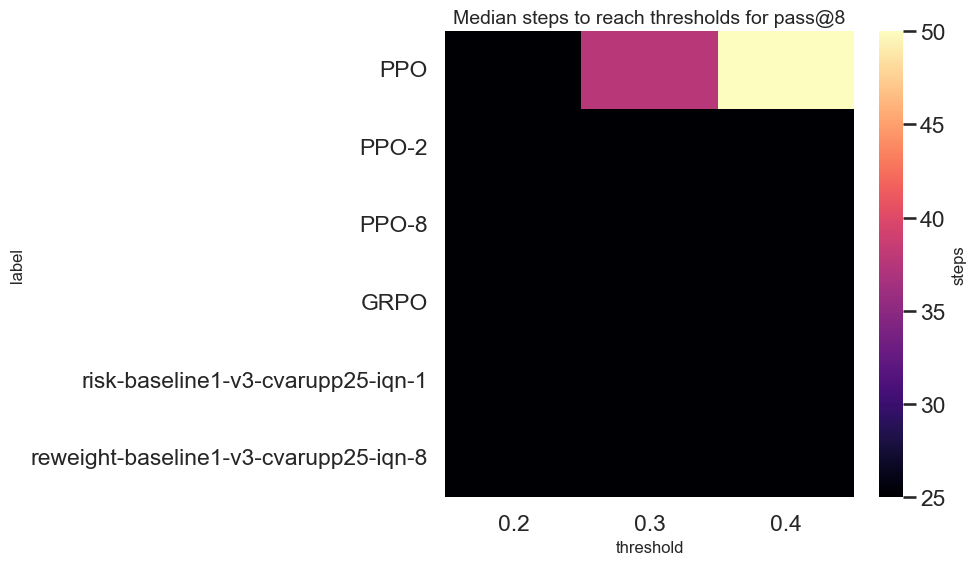

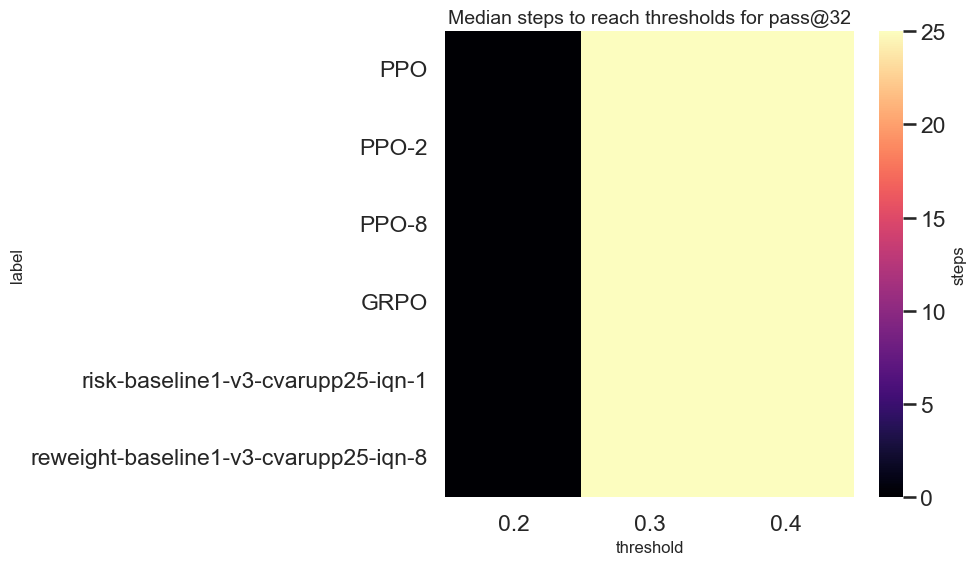

In [3]:
# Plot 1: heatmap of median step to reach threshold
for metric in metrics:
    sub = hits[hits["metric"] == metric]
    pivot = sub.pivot_table(index="label", columns="threshold", values="step", aggfunc="median")
    pivot = pivot.reindex(focus_labels)
    new_fig(f"Median steps to reach thresholds for {metric}")
    sns.heatmap(pivot, annot=False, cmap="magma", cbar_kws={"label": "steps"})
    plt.tight_layout()
    plt.show()


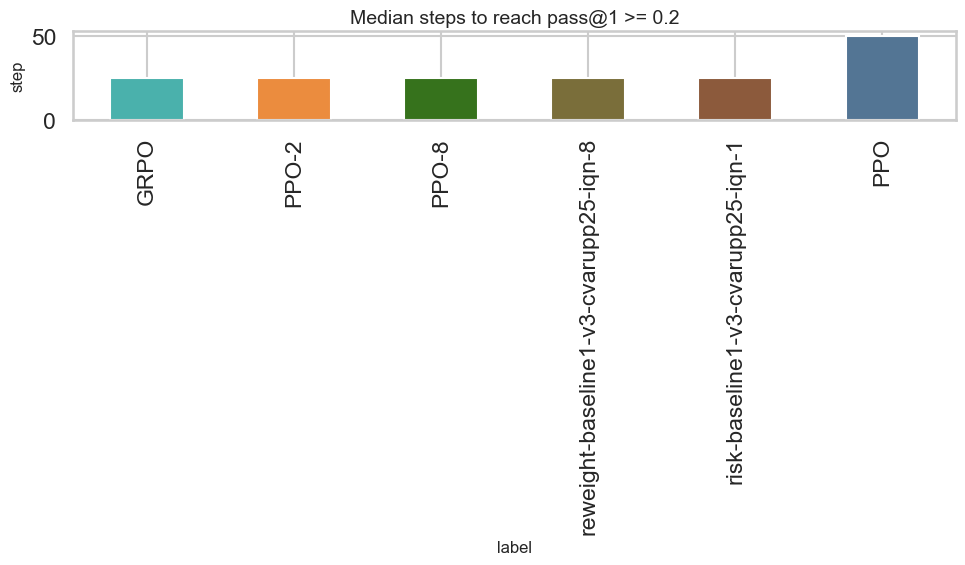

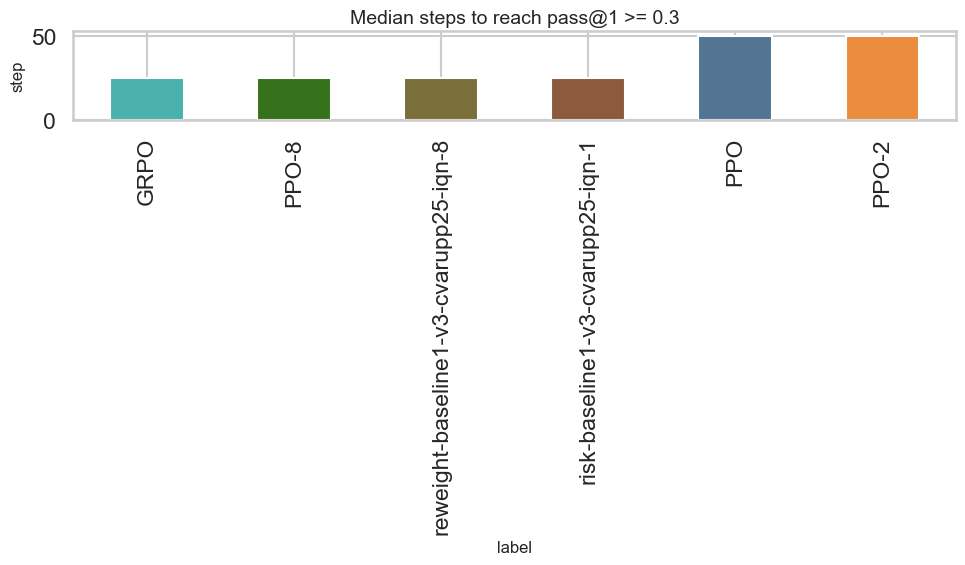

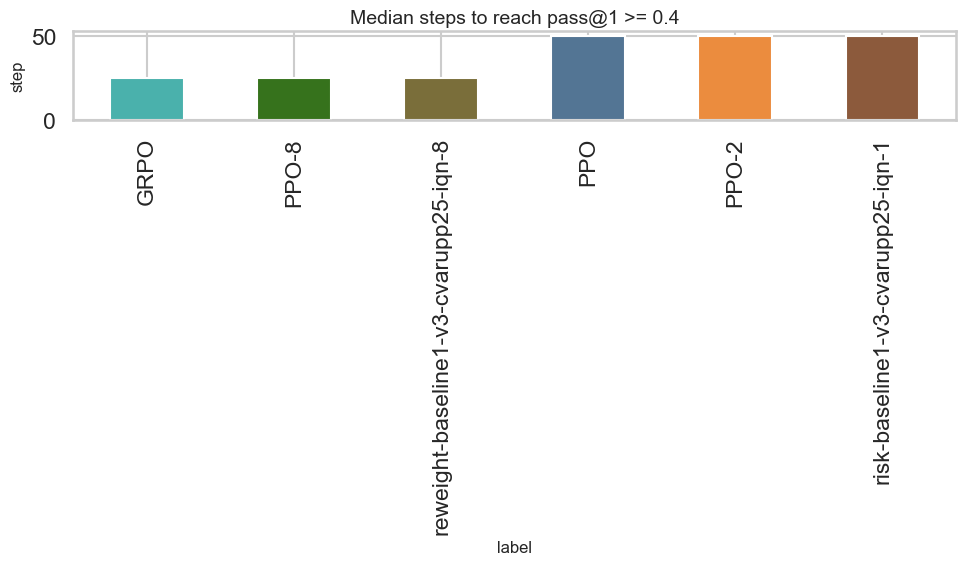

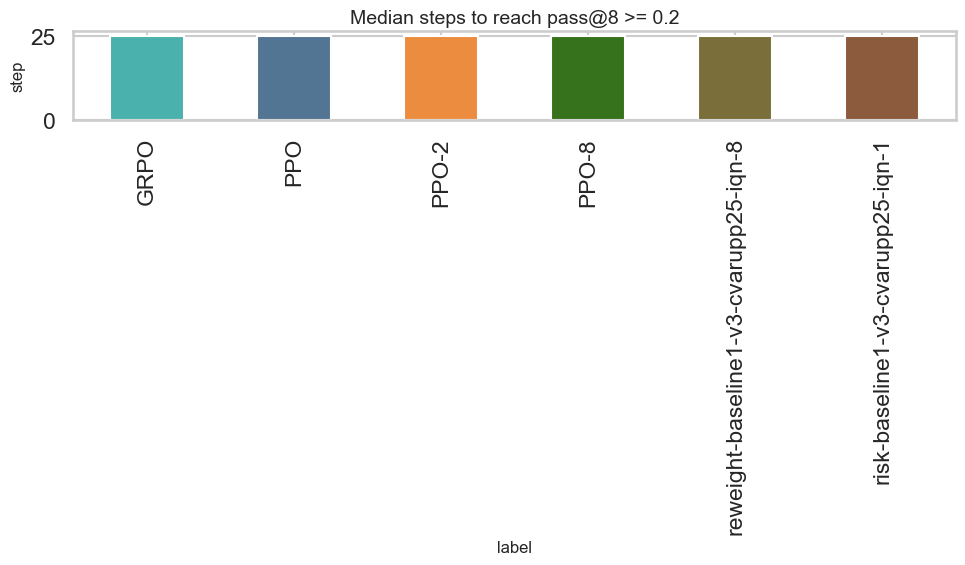

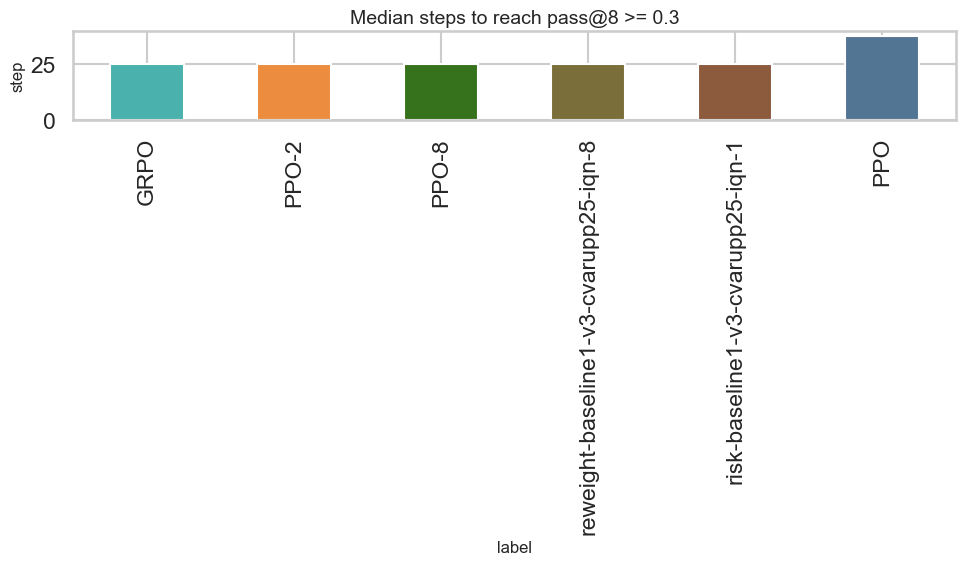

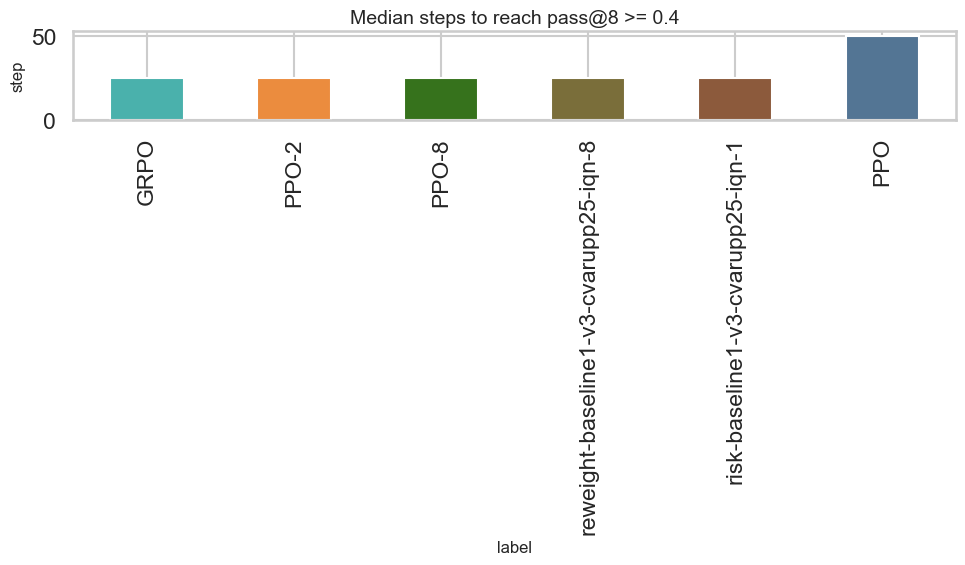

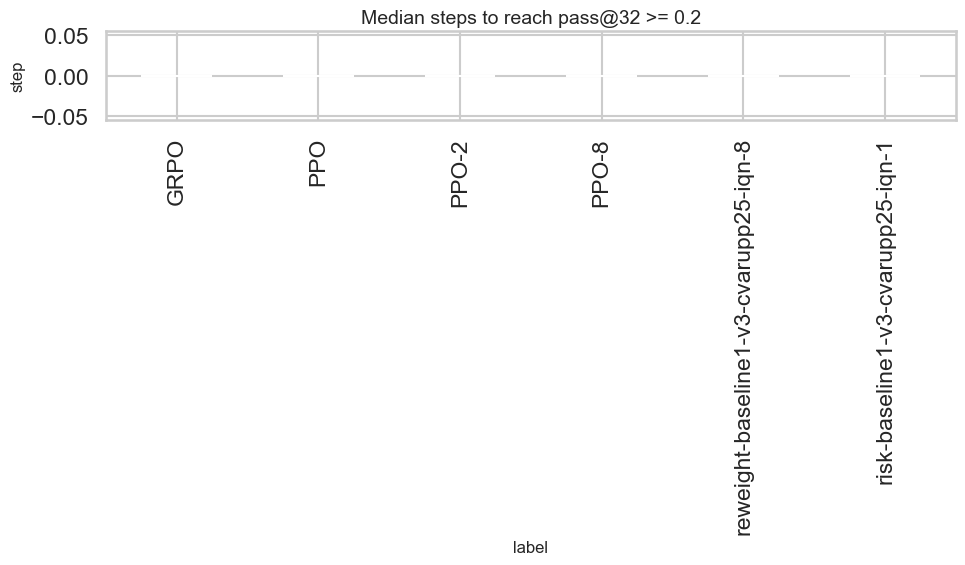

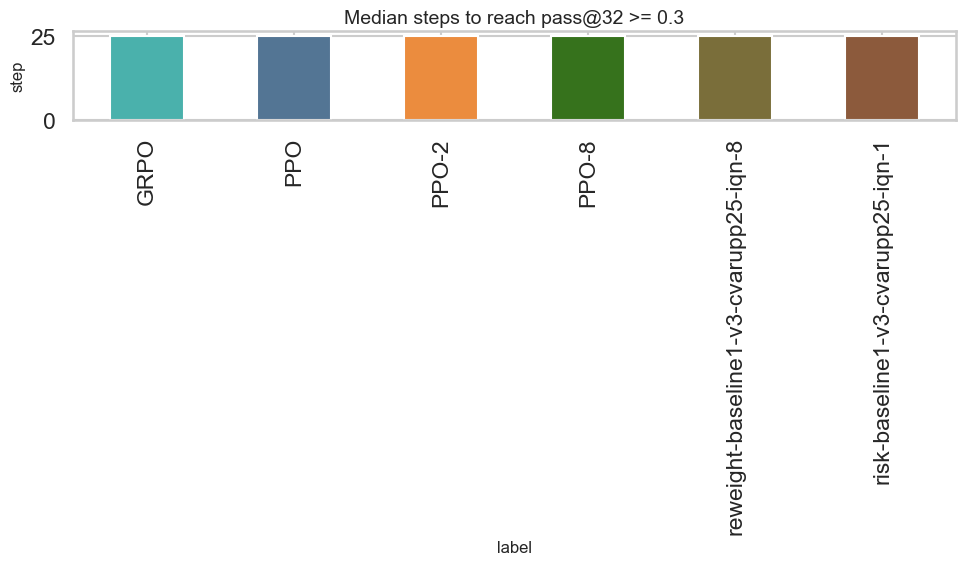

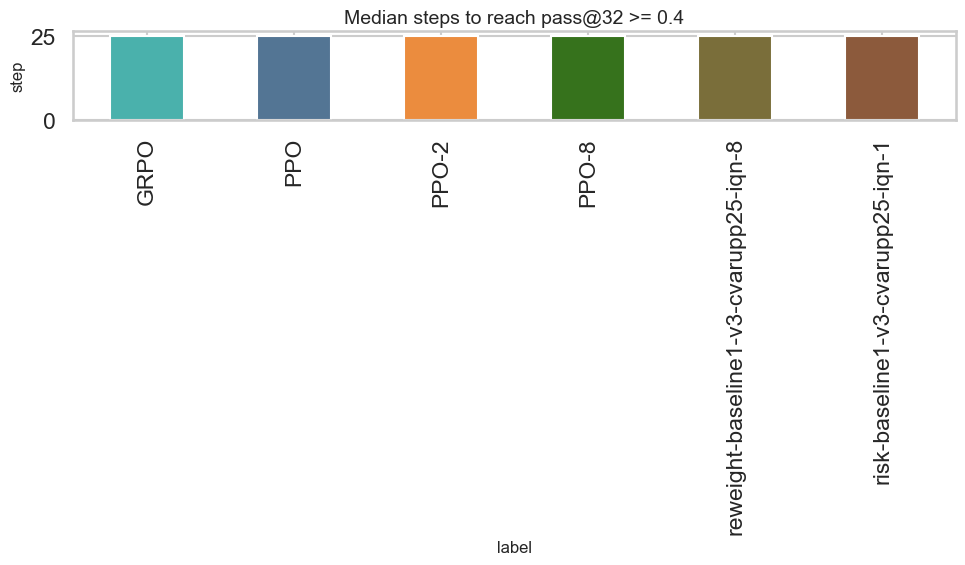

In [4]:
# Plot 2: bar plots by threshold
for metric in metrics:
    for thr in thresholds:
        sub = hits[(hits["metric"] == metric) & (hits["threshold"] == thr)]
        summary = sub.groupby("label")["step"].median().sort_values()
        new_fig(f"Median steps to reach {metric} >= {thr}")
        summary.plot(kind="bar", color=[color_map[l] for l in summary.index])
        plt.ylabel("step")
        plt.tight_layout()
        plt.show()


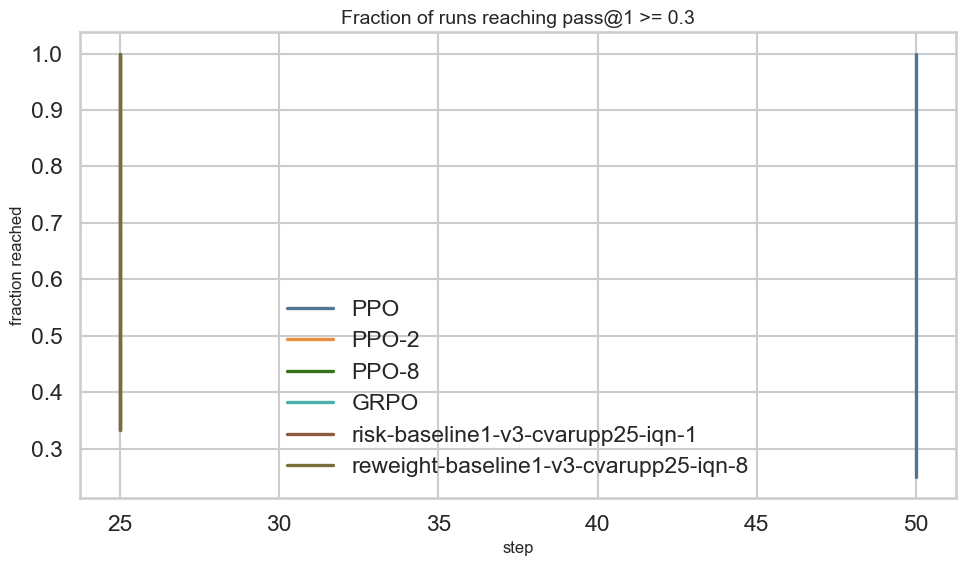

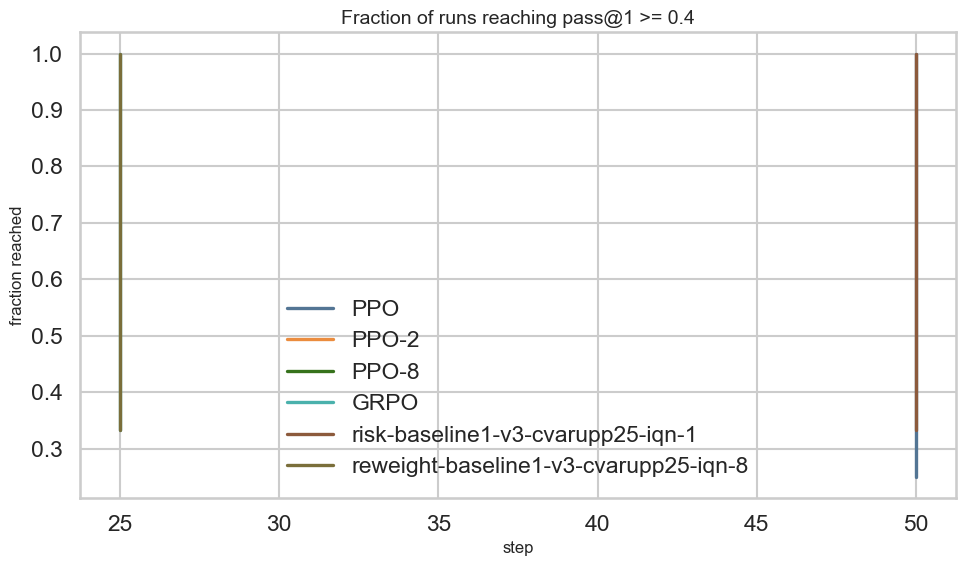

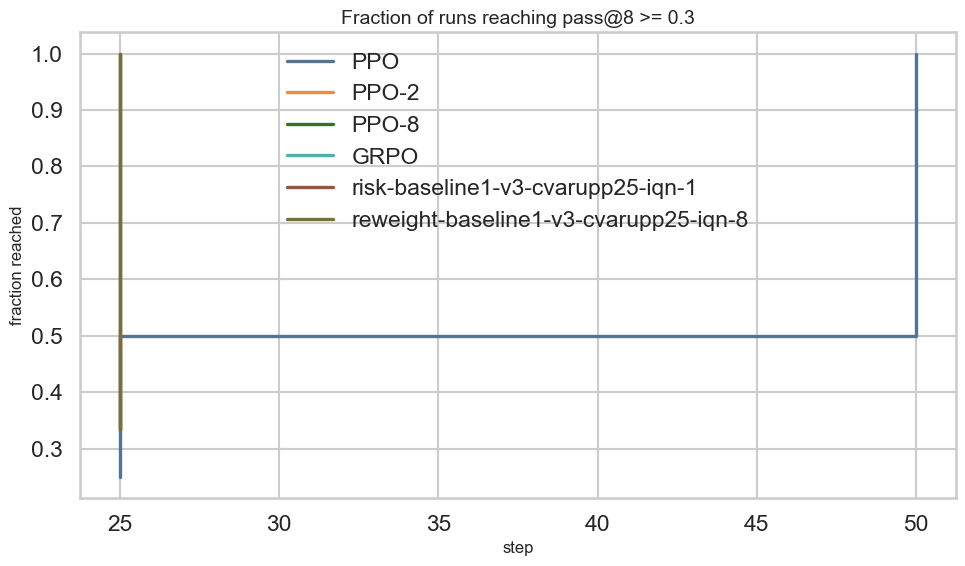

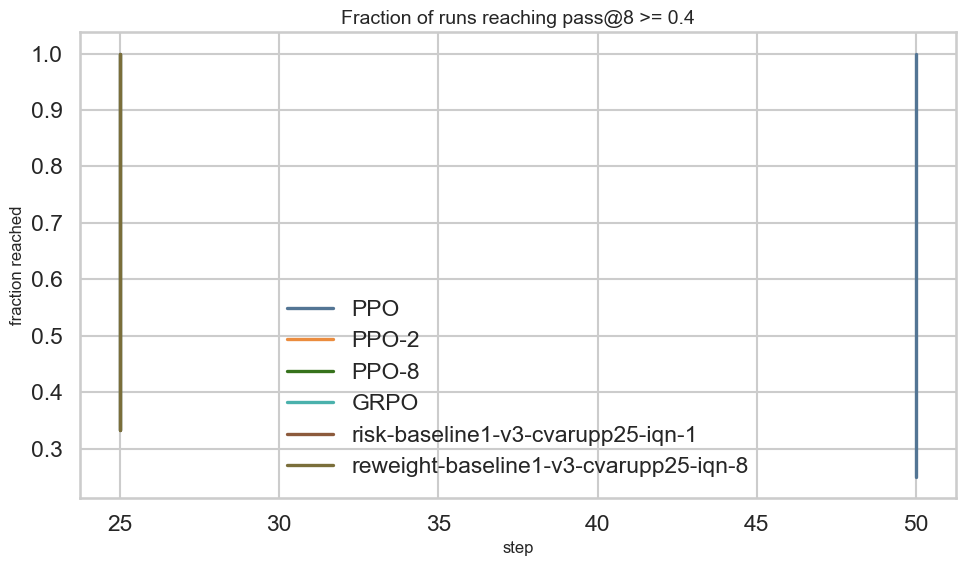

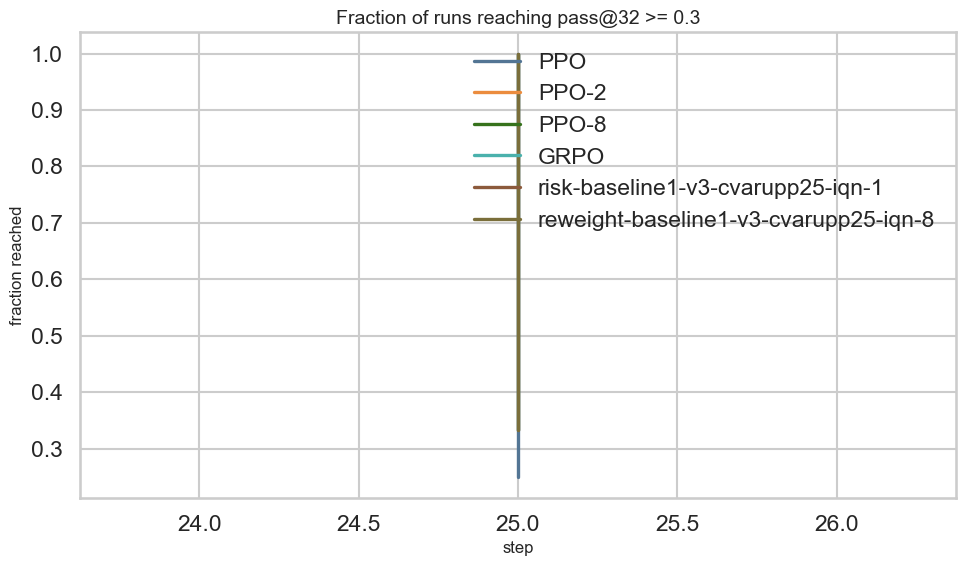

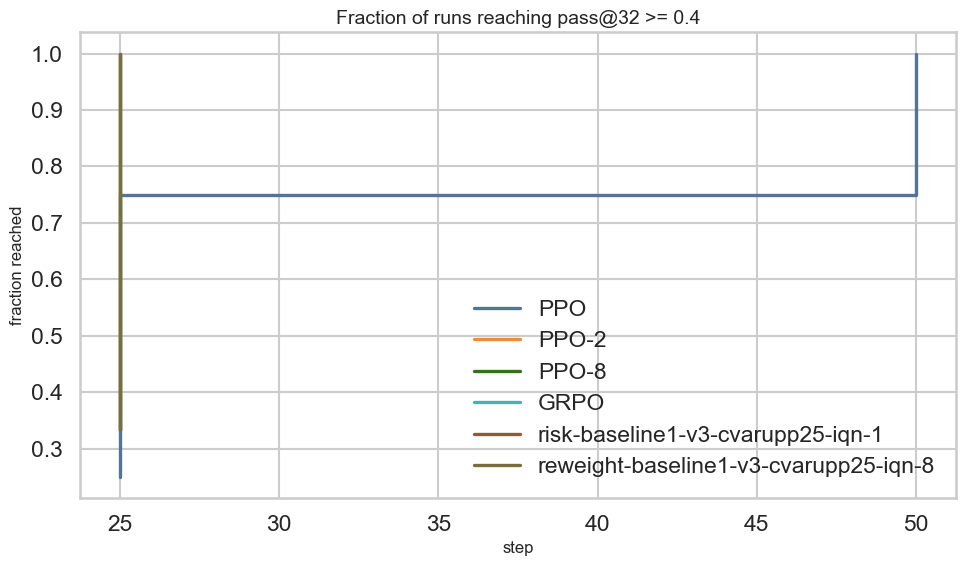

In [5]:
# Plot 3: success-rate over steps (CDF style)
for metric in metrics:
    for thr in [0.3, 0.4]:
        new_fig(f"Fraction of runs reaching {metric} >= {thr}")
        for algo in focus_labels:
            sub = hits[(hits["metric"] == metric) & (hits["threshold"] == thr) & (hits["label"] == algo)]
            # build cumulative curve of % reached by step
            steps = sub["step"].dropna().values
            if len(steps) == 0:
                continue
            steps = np.sort(steps)
            y = np.arange(1, len(steps) + 1) / len(steps)
            plt.step(steps, y, where="post", label=algo, color=color_map[algo], linewidth=2.4)
        plt.xlabel("step")
        plt.ylabel("fraction reached")
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()


/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_63757/260849653.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucs = agg.groupby("label").apply(lambda df: np.trapz(df[metric], df["Step"]))


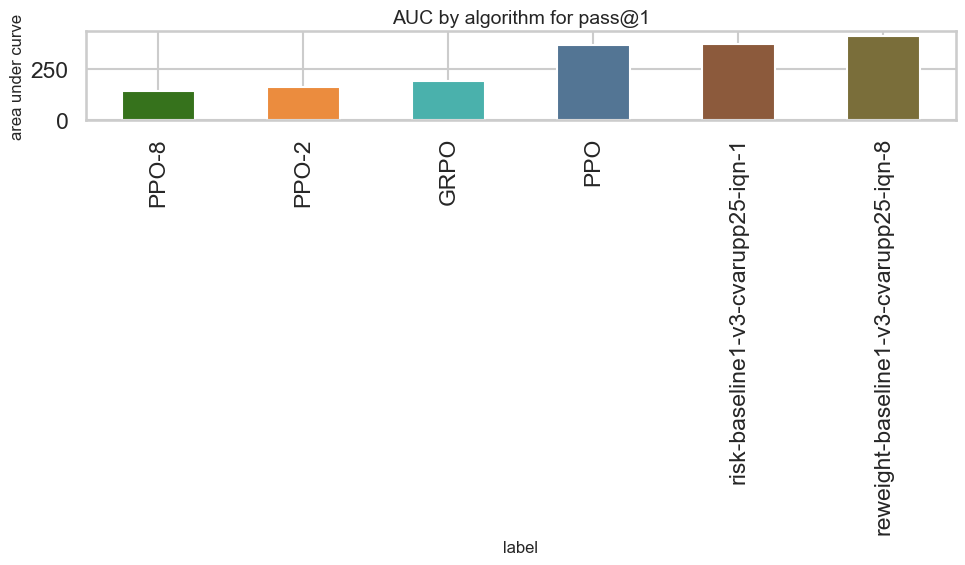

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_63757/260849653.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucs = agg.groupby("label").apply(lambda df: np.trapz(df[metric], df["Step"]))


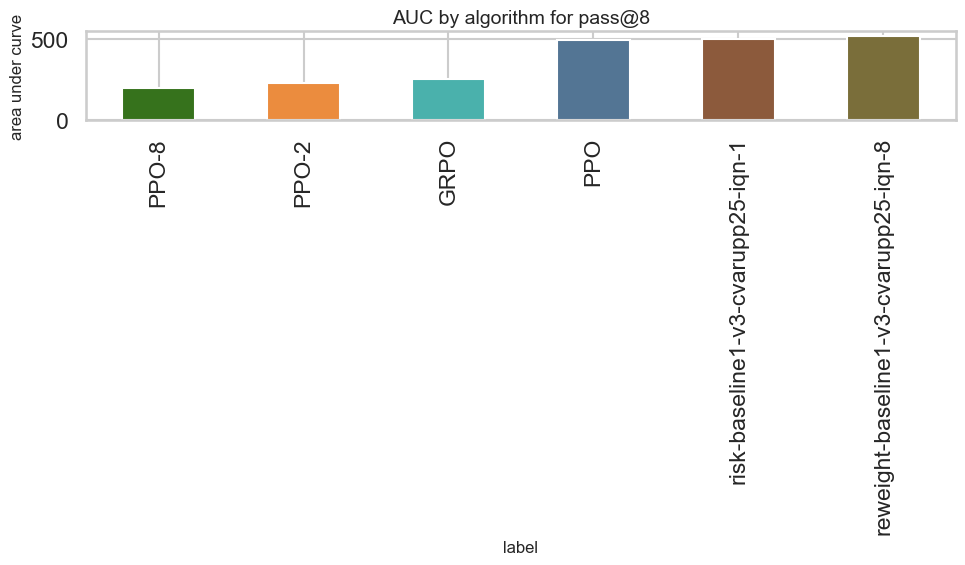

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_63757/260849653.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucs = agg.groupby("label").apply(lambda df: np.trapz(df[metric], df["Step"]))


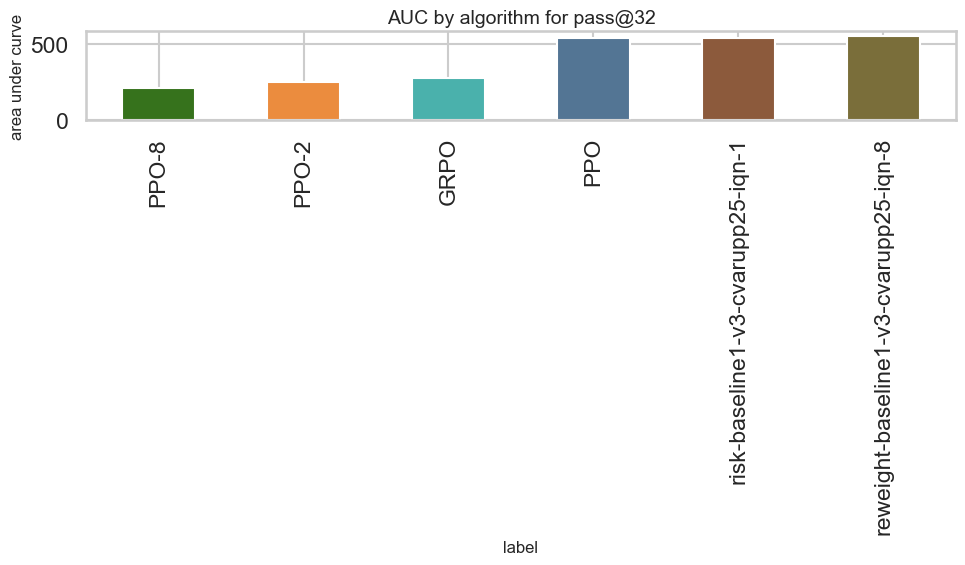

Generated 21 figures


In [6]:
# Plot 4: AUC across steps for each metric
for metric in metrics:
    aucs = agg.groupby("label").apply(lambda df: np.trapz(df[metric], df["Step"]))
    aucs = aucs.sort_values()
    new_fig(f"AUC by algorithm for {metric}")
    aucs.plot(kind="bar", color=[color_map[l] for l in aucs.index])
    plt.ylabel("area under curve")
    plt.tight_layout()
    plt.show()

print(f"Generated {PLOT_COUNTER} figures")


In [7]:
# AUC table for alternative visualizations
auc_records = []
for metric in metrics:
    for label in focus_labels:
        sub = agg[agg["label"] == label].sort_values("Step")
        auc = np.trapz(sub[metric], sub["Step"])
        auc_records.append({"metric": metric, "label": label, "auc": auc})

auc_df = pd.DataFrame(auc_records)


/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_63757/2675301990.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(sub[metric], sub["Step"])


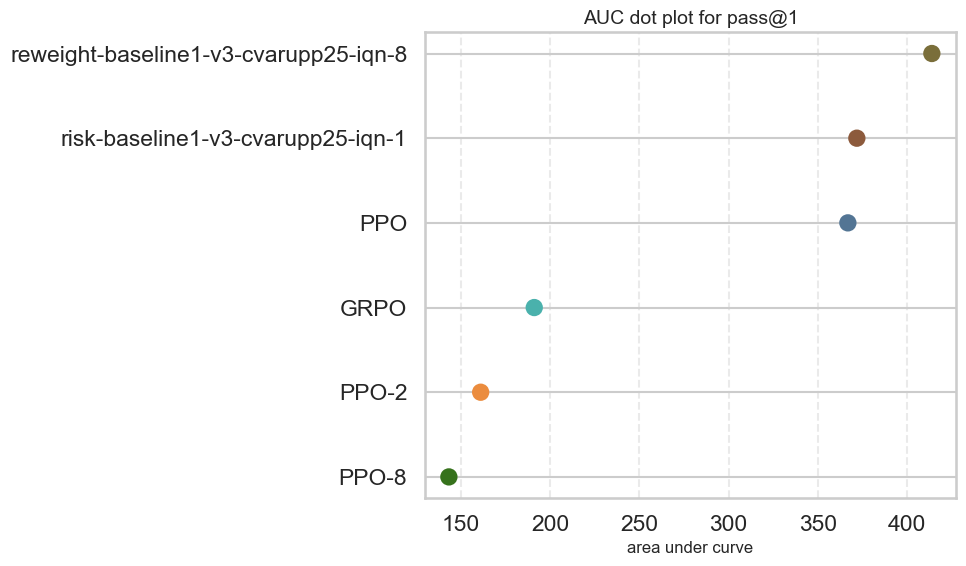

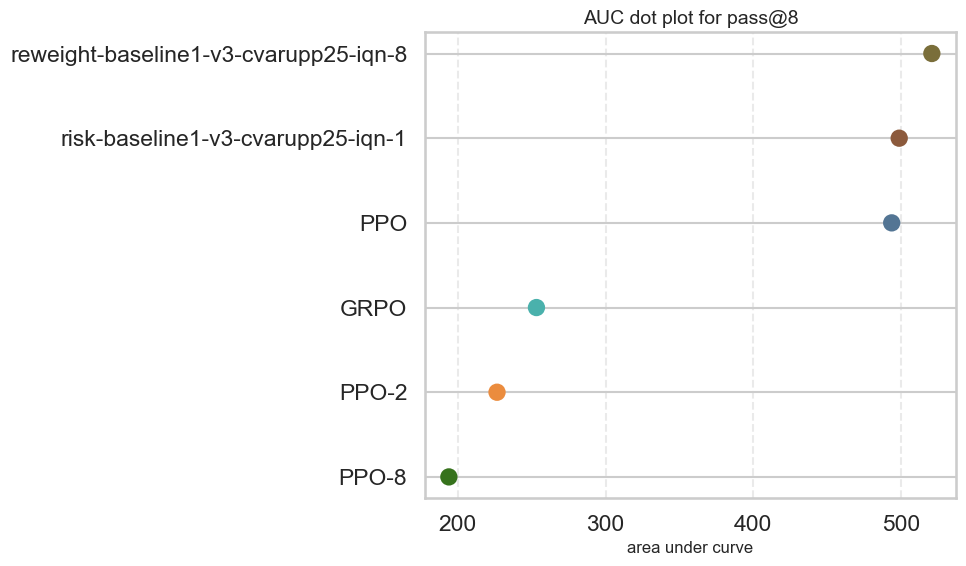

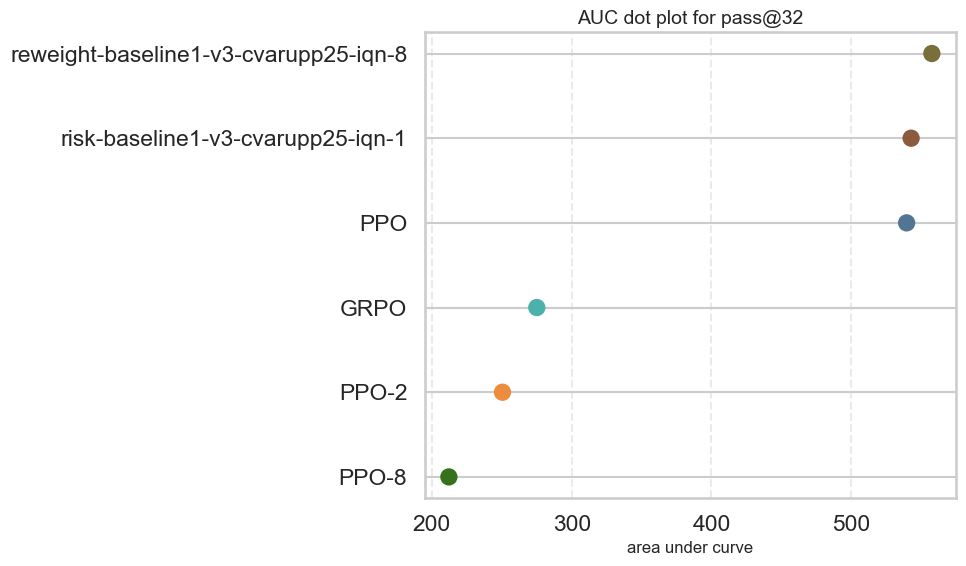

In [8]:
# Plot 5: AUC dot plot (sorted)
for metric in metrics:
    sub = auc_df[auc_df["metric"] == metric].set_index("label")
    sub = sub.loc[focus_labels]
    sub = sub.sort_values("auc")
    new_fig(f"AUC dot plot for {metric}")
    y_pos = np.arange(len(sub))
    plt.scatter(sub["auc"], y_pos, s=120, color=[color_map[l] for l in sub.index])
    plt.yticks(y_pos, sub.index)
    plt.xlabel("area under curve")
    plt.grid(True, axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


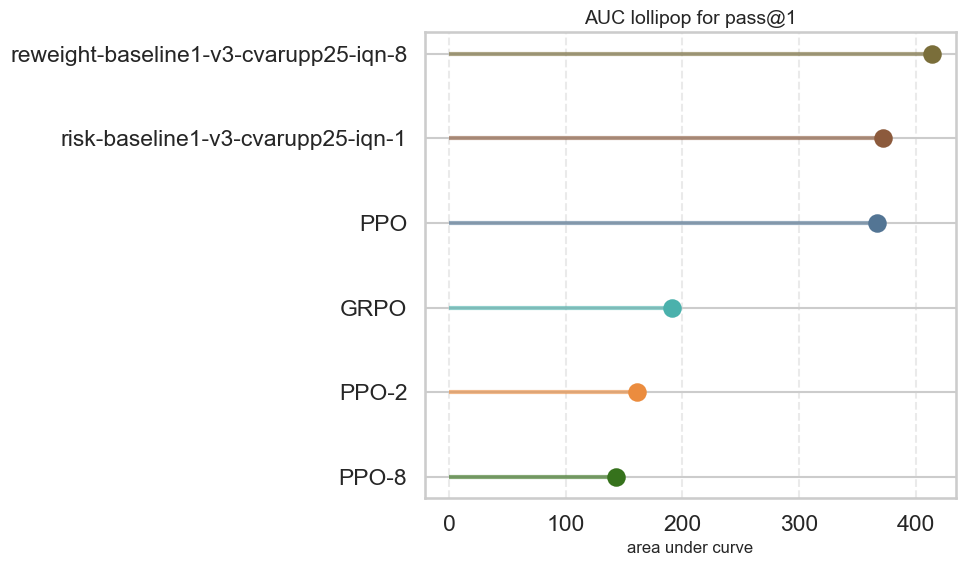

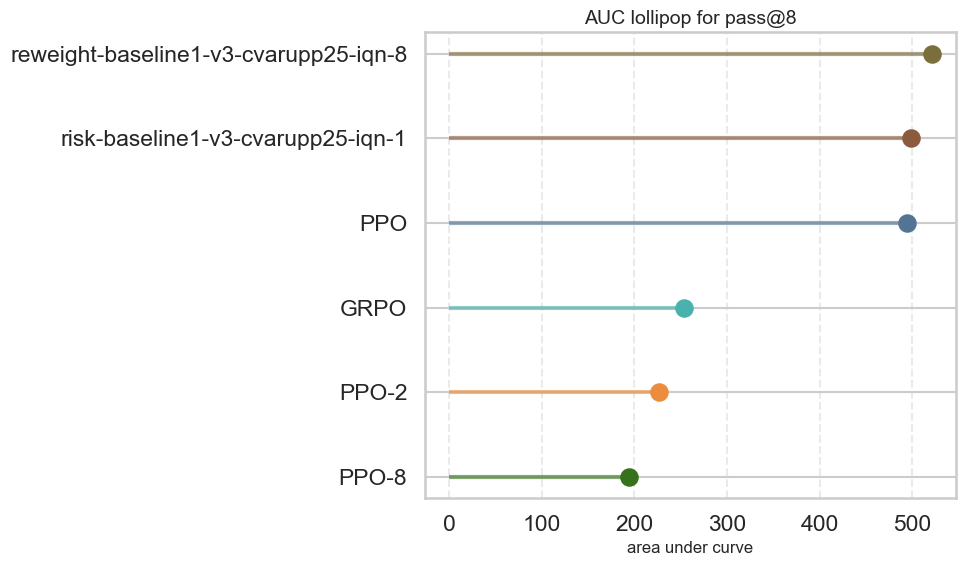

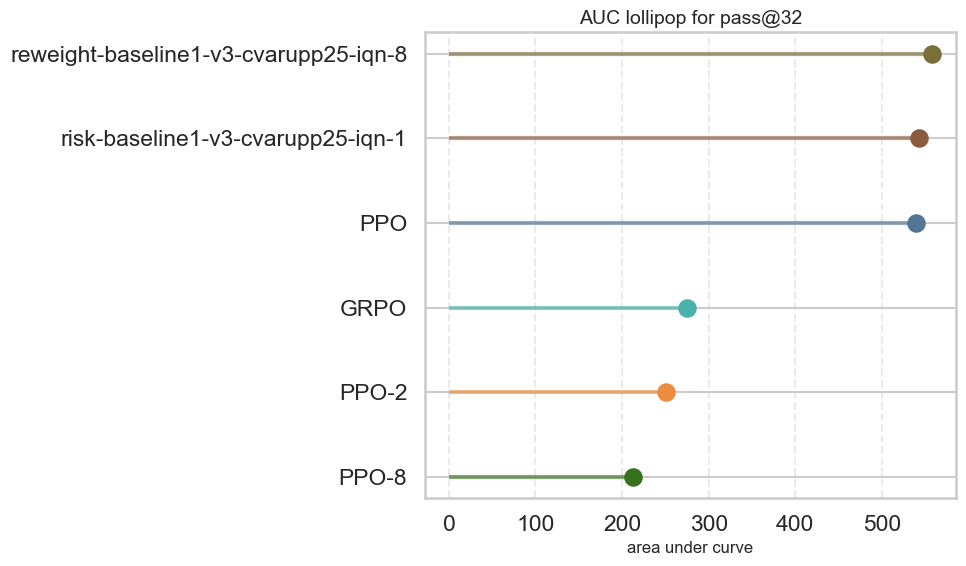

In [9]:
# Plot 6: AUC lollipop chart
for metric in metrics:
    sub = auc_df[auc_df["metric"] == metric].set_index("label")
    sub = sub.loc[focus_labels]
    sub = sub.sort_values("auc")
    new_fig(f"AUC lollipop for {metric}")
    y_pos = np.arange(len(sub))
    for i, (label, row) in enumerate(sub.iterrows()):
        plt.hlines(y=i, xmin=0, xmax=row["auc"], color=color_map[label], alpha=0.6, linewidth=3)
        plt.scatter(row["auc"], i, color=color_map[label], s=140, zorder=3)
    plt.yticks(y_pos, sub.index)
    plt.xlabel("area under curve")
    plt.grid(True, axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


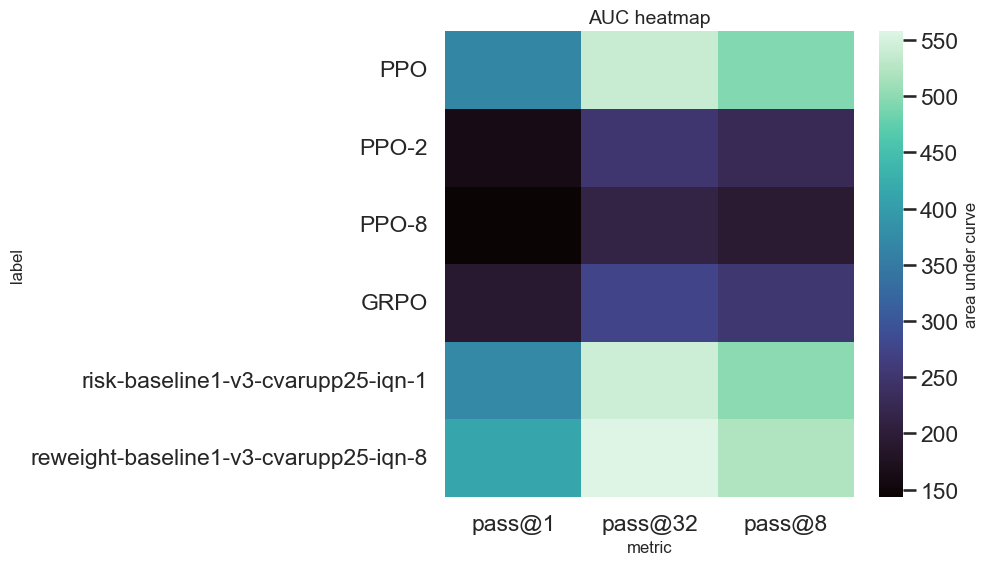

In [10]:
# Plot 7: AUC heatmap (algorithm x metric)
pivot = auc_df.pivot(index="label", columns="metric", values="auc").reindex(focus_labels)
new_fig("AUC heatmap")
sns.heatmap(pivot, annot=False, cmap="mako", cbar_kws={"label": "area under curve"})
plt.tight_layout()
plt.show()


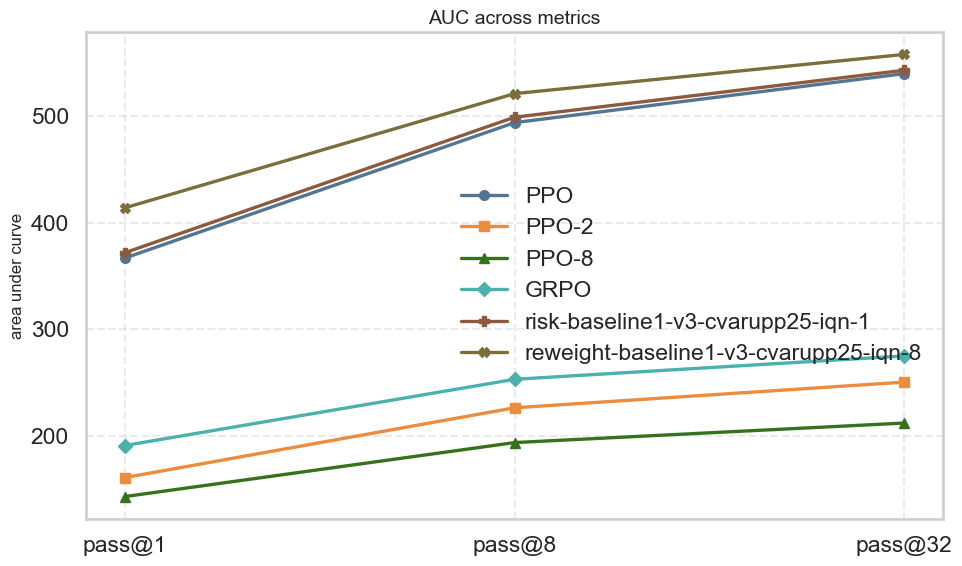

In [11]:
# Plot 8: AUC across metrics (lines by algorithm)
pivot = auc_df.pivot(index="label", columns="metric", values="auc").reindex(focus_labels)
new_fig("AUC across metrics")
x = np.arange(len(metrics))
for label in focus_labels:
    y = pivot.loc[label, metrics].to_numpy()
    plt.plot(x, y, marker=marker_map[label], linewidth=2.4, markersize=7, label=label, color=color_map[label])
plt.xticks(x, metrics)
plt.ylabel("area under curve")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
